# Лабораторная работа №6 (2)

Данные в файле  `M3C.xls`
Данные по годам. 

Задача:
1. Выбрать 3 ряда
2. Подобрать параметры модели ARIMA
3. Описать процедуру подбора в комментариях
4. Построить прогноз на 4 года вперед

In [3]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [4]:
# 148 363 390
row148 = np.array([5929.07, 6332.38, 6043.28, 6127.9, 6262.29, 6416.96, 5999.64, 6424.27, 5769.61, 5623.18, 5357.77, 5265, 4900.33, 4529.55, 4130.8, 4225.07, 4181.2, 4189.48, 3988.72, 3863.11, 3719.97, 3591.07, 3391.82, 3031.74, 2650.98, 2409.32, 2300.46, 2351.41, 2104.9, 1845.68, 1673.86, 1678.03])
row363 = np.array([1305, 1410, 1330, 1310, 1430, 1480, 1600, 1450, 1530, 1680, 1945, 1895, 2190, 2205, 2175, 2165, 2130, 2200, 2245, 2565, 2755, 3090, 3515, 4020, 3695, 3605, 3720, 4285, 4415, 4215, 4010, 4365, 4815, 5970, 7085, 6895, 6020, 6355, 5685, 4510, 4690, 4855, 4630, 4660, 4385, 4070, 3610])
row390 = np.array([1045.24, 1056.1, 1061.64, 1067.64, 1076.17, 1092.87, 1104.63, 1117.47, 1129.19, 1142.13, 1155.74, 1171.17, 1191.06, 1206.71, 1222.14, 1244.22, 1265.03, 1284.59, 1301.8, 1320.92, 1342.81, 1365.73, 1392.03, 1421.89, 1459.39, 1488.7, 1518.41, 1548.31, 1578.18, 1606.89, 1635.41, 1664.6, 1693.49, 1717.75, 1739.39, 1758.91, 1780.8, 1799.12, 1822.93, 1844.9, 1863.22, 1880.81, 1896.86, 1913.29, 1931.42, 1950.34])
df = pd.DataFrame({
    '148': pd.Series(row148),
    '363': pd.Series(row363),
    '390': pd.Series(row390)
})

In [26]:
forecast_periods = 4

def func(y, col):
    # визуализация исходного ряда
	_, ax = plt.subplots(figsize = (12, 5))

	y.plot(ax = ax, grid = True, linewidth = 1.5, marker = 'o', markersize = 3, title = f'Ряд {col}')
	y = y.dropna()
	
	# проверка на стационарность
	adf_result = adfuller(y)
	print(f'p-value: {adf_result[1]:.6f}')
 
	is_stationary = adf_result[1] < 0.05
	print(f'Ряд стационарен: {is_stationary}')
 
	d = 0
	if not is_stationary:
		
		y_diff = y.diff().dropna()
		adf_diff = adfuller(y_diff)
		print(f'После первой дифференцировки, p-value: {adf_diff[1]:.6f}')
		d = 1
		if adf_diff[1] >= 0.05:
			
			y_diff = y_diff.diff().dropna()
			adf_diff2 = adfuller(y_diff)
			print(f'После второй дифференцировки, p-value: {adf_diff2[1]:.6f}')
			d = 2

	print(f'Степень дифференцирования (d): {d}')
 
	y_for_acf = y_diff if d > 0 else y

	# максимальное количество лагов ограничено 50% размера выборки для PACF
	max_lags = min(15, len(y_for_acf) // 2 - 1)

	fig, axes = plt.subplots(1, 2, figsize=(14, 5))

	# ACF график
	plot_acf(y_for_acf, lags=max_lags, ax=axes[0])
	axes[0].set_title('Автокорреляционная функция (ACF)')
	axes[0].set_xlabel('Лаги')

	# PACF график
	plot_pacf(y_for_acf, lags=max_lags, ax=axes[1], method='ywm')
	axes[1].set_title('Частная автокорреляционная функция (PACF)')
	axes[1].set_xlabel('Лаги')

	plt.tight_layout()
	plt.show()
	
	# автоматический подбор параметров модели
	model = auto_arima(
		y,
		max_p=3,
		max_d=2,
		max_q=3,
		seasonal=False,
		stepwise=True,
		trace=True,
		error_action='ignore',
		suppress_warnings=True
	)

	p, d, q = model.order
	f'p, d, q: {p}, {d}, {q}'
	
	# прогноз  
	forecast = model.predict(n_periods=forecast_periods)
 
	_, ax = plt.subplots(figsize=(14, 6))

	ax.plot(y.index, y.values, '-', label='Исходные данные', linewidth=2, marker='o', markersize=4)

	# подогнанные значения
	fitted_values = model.predict_in_sample()
	ax.plot(range(len(y)), fitted_values, 'g--', label='Подогнанные значения', linewidth=1.5, alpha=0.8)

	# прогноз
	forecast_index = range(len(y), len(y) + forecast_periods)
	ax.plot(forecast_index, forecast, 'r-o', label='Прогноз', linewidth=2, markersize=6)

	ax.axvline(x=len(y)-0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
	ax.set_xlabel('Периоды времени')
	ax.set_ylabel('Значение')
	ax.set_title(f'Прогноз ARIMA({p},{d},{q}) на 4 периода')
	ax.legend()
	ax.grid(True)

	plt.tight_layout()
	plt.show()
 
	# метрики
	mae = mean_absolute_error(y, fitted_values)
	mape = mean_absolute_percentage_error(y, fitted_values)

	print(f"MAE: {mae:.4f}")
	print(f"MAPE: {mape:.2%}")	

p-value: 0.992012
Ряд стационарен: False
После первой дифференцировки, p-value: 0.000090
Степень дифференцирования (d): 1


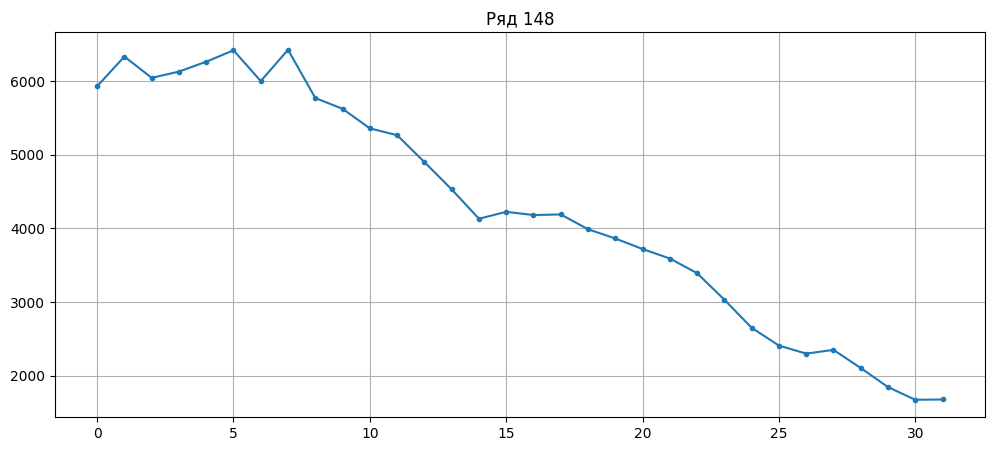

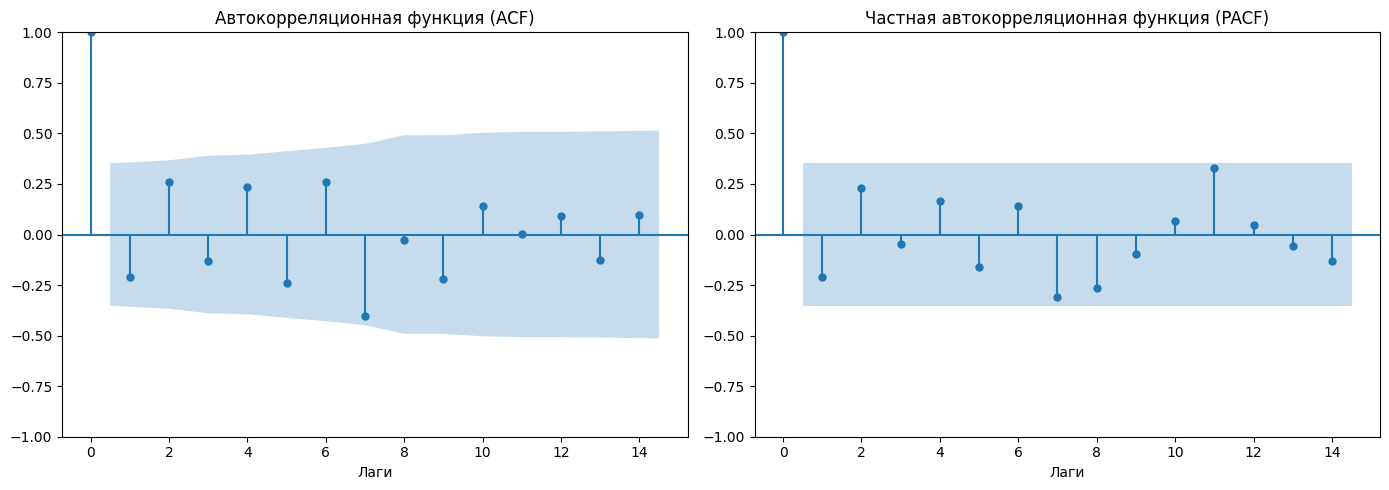

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=429.777, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=431.352, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=431.495, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=437.038, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=429.754, Time=0.30 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=431.262, Time=0.38 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=432.251, Time=0.24 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=431.627, Time=0.20 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=435.028, Time=0.15 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 2.233 seconds


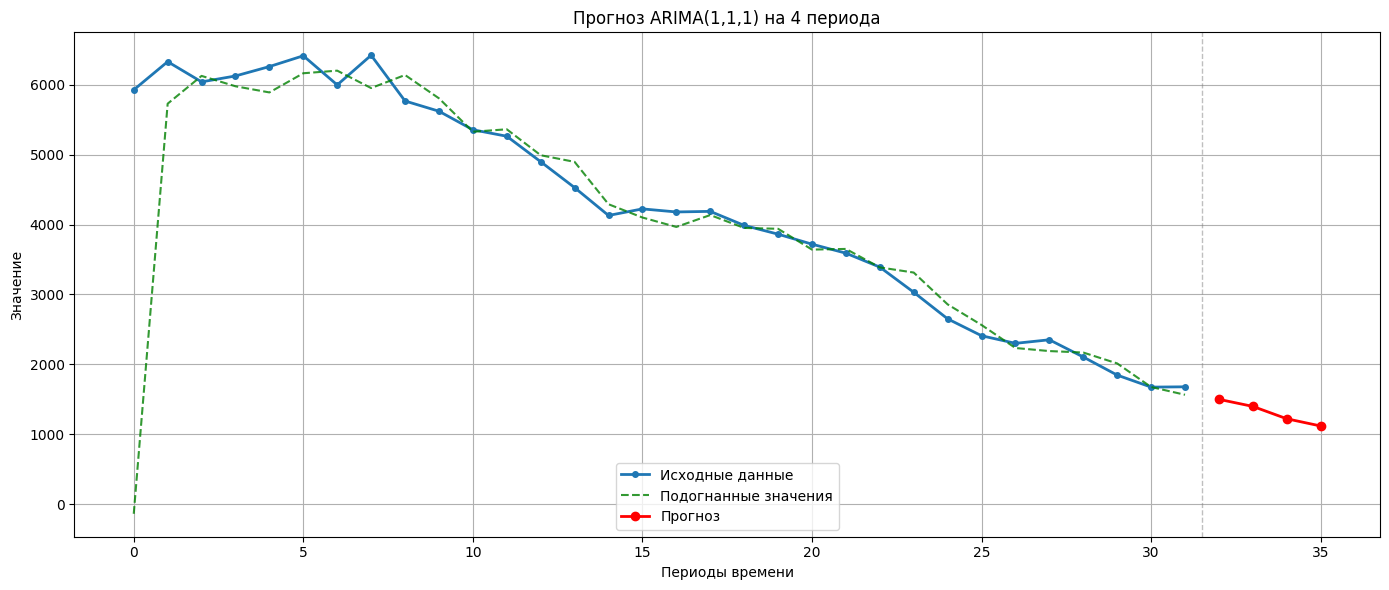

MAE: 355.2634
MAPE: 7.21%
p-value: 0.521093
Ряд стационарен: False
После первой дифференцировки, p-value: 0.000197
Степень дифференцирования (d): 1


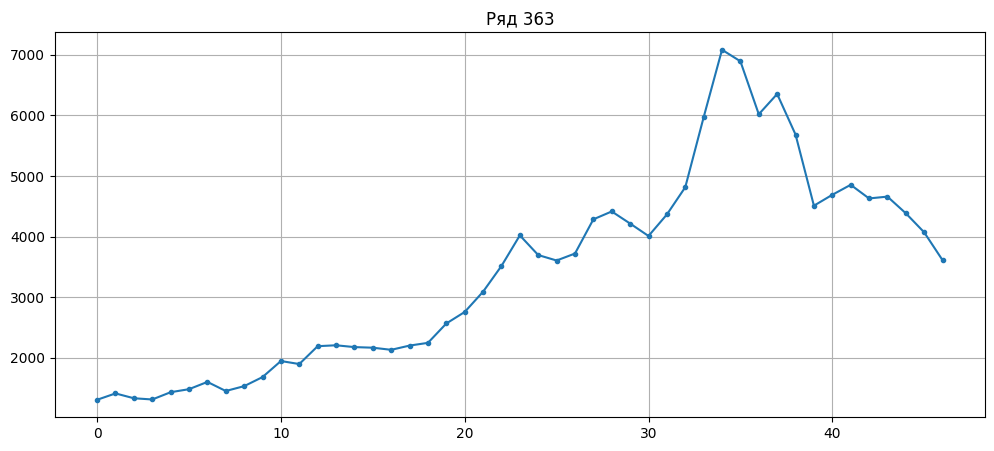

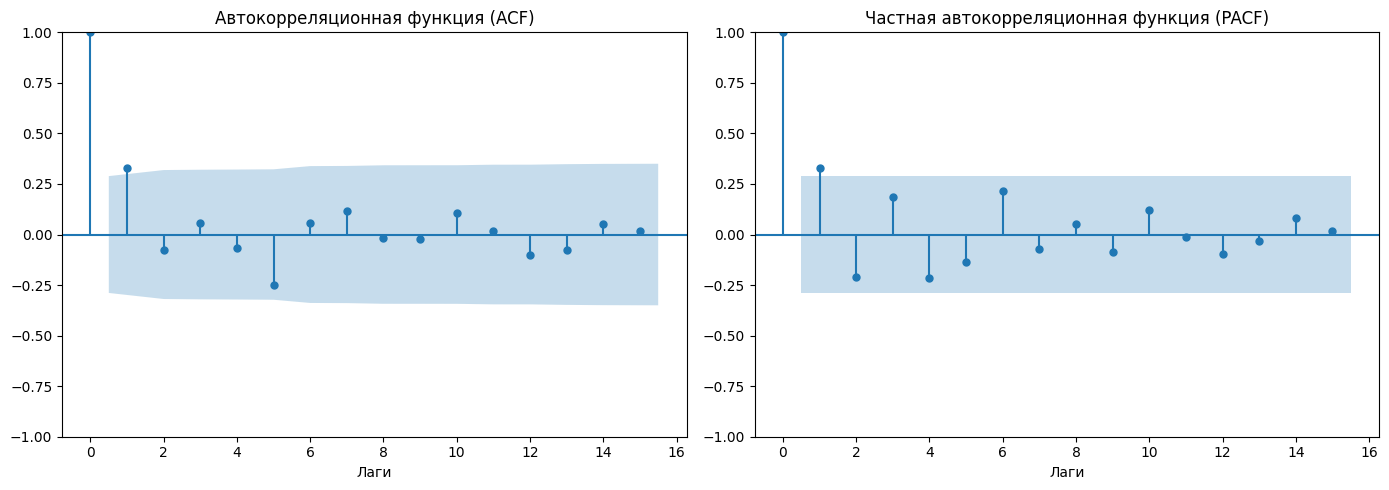

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=686.823, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=683.402, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=680.073, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=685.523, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=681.898, Time=0.23 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=681.855, Time=0.23 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=683.779, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=678.353, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=680.238, Time=0.11 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=680.212, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=681.653, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=679.913, Time=0.18 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.723 seconds


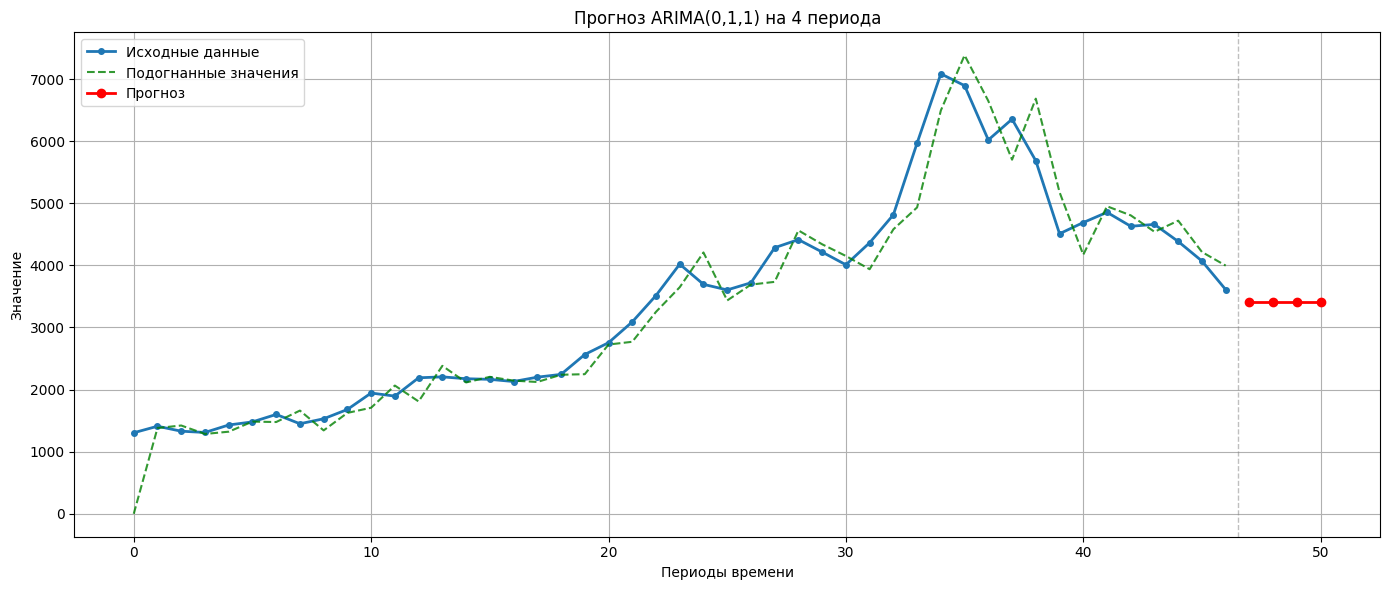

MAE: 293.2905
MAPE: 9.29%
p-value: 0.940387
Ряд стационарен: False
После первой дифференцировки, p-value: 0.347258
После второй дифференцировки, p-value: 0.000000
Степень дифференцирования (d): 2


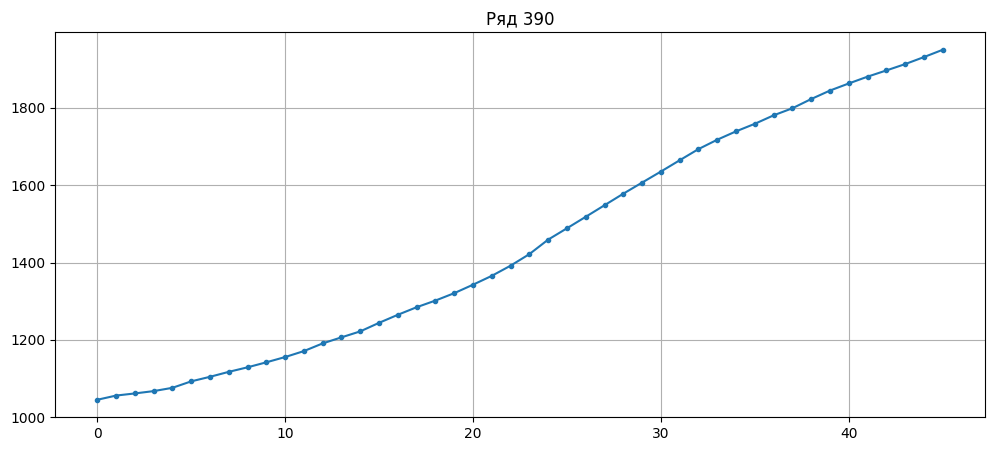

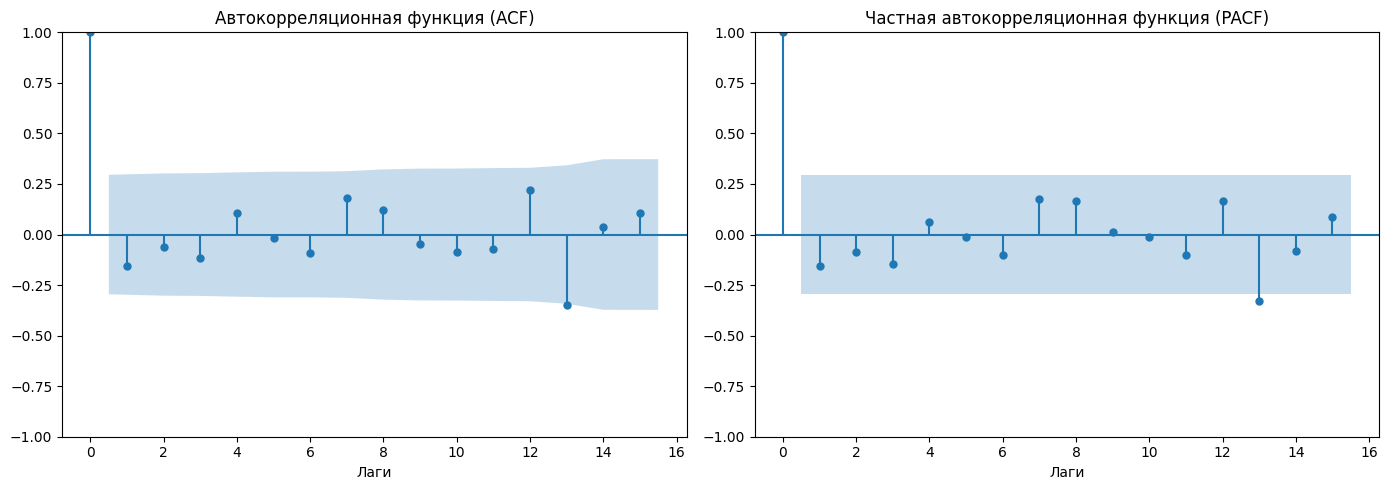

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.57 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=235.069, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=235.958, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=235.680, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=233.201, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=237.322, Time=0.10 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 0.820 seconds


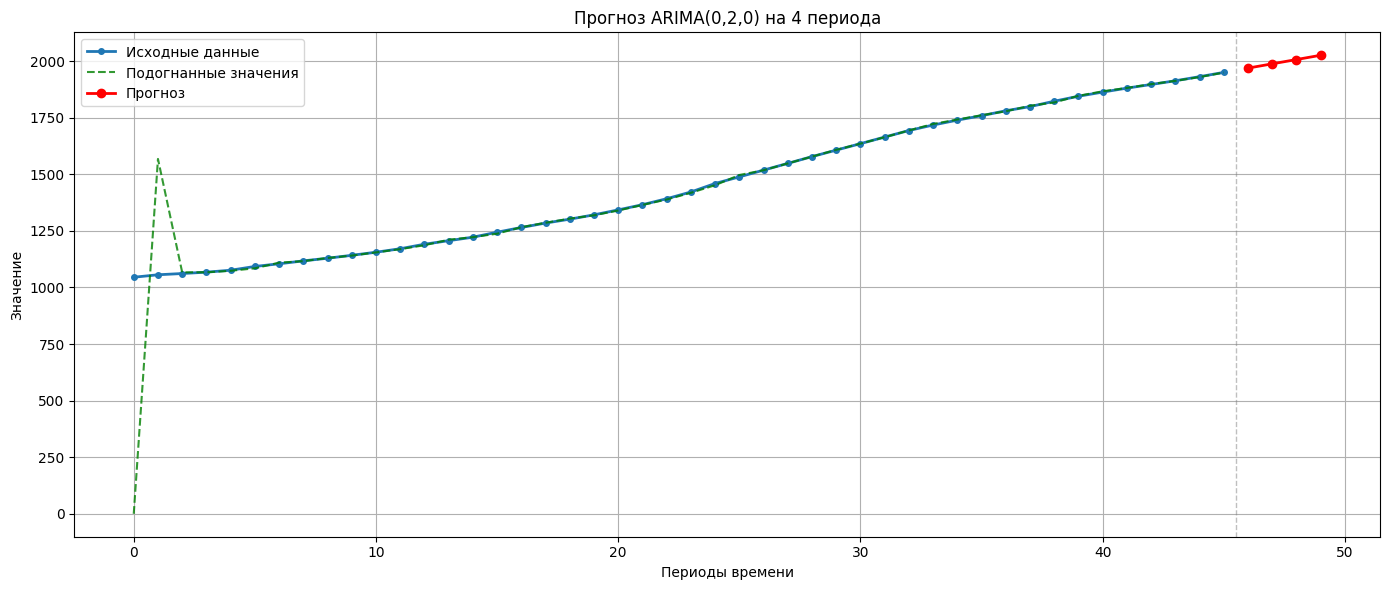

MAE: 36.2527
MAPE: 3.40%


In [27]:
for col in df.columns:
	func(df[col], col)